authors: [Ali Ismail-Fawaz](https://hadifawaz1999.github.io/) and [Germain Forestier](https://germain-forestier.info/)

# Deep Learning: Introduction

## Import used packages

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D

## Downloading the dataset

In [3]:
!wget https://hadifawaz1999.github.io/teaching/Ensisa/2A-Info/DeepLearning/datasets/pokemon-stats-data.csv

--2026-01-14 09:56:30--  https://hadifawaz1999.github.io/teaching/Ensisa/2A-Info/DeepLearning/datasets/pokemon-stats-data.csv
Resolving hadifawaz1999.github.io (hadifawaz1999.github.io)... 185.199.109.153, 185.199.110.153, 185.199.111.153, ...
Connecting to hadifawaz1999.github.io (hadifawaz1999.github.io)|185.199.109.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22598 (22K) [text/csv]
Saving to: ‘pokemon-stats-data.csv.2’

pokemon-stats-data. 100%[===================>]  22.07K  --.-KB/s    in 0.003s  

2026-01-14 09:56:30 (8.31 MB/s) - ‘pokemon-stats-data.csv.2’ saved [22598/22598]



## Reading the data

In [4]:
df = pd.read_csv("pokemon-stats-data.csv")

df = df.dropna()
df.head()

,name,weight_kg,speed,sp_attack,sp_defense,type
0,Bulbasaur,6.9,45,65,65,grass
1,Ivysaur,13.0,60,80,80,grass
2,Venusaur,100.0,80,122,120,grass
3,Charmander,8.5,65,60,50,fire
4,Charmeleon,19.0,80,80,65,fire


## Extract the features to be used

In [5]:
X = df["sp_attack"]
Y = df["sp_defense"]

print("Number of samples in the dataset is "+str(len(X)))

Number of samples in the dataset is 781


## Split the dataset into train and test sets

In [6]:
xtrain, xtest, ytrain, ytest = train_test_split(X, Y, test_size=33/100, random_state=42)

print("Number of training examples is "+str(len(xtrain)))
print("Number of testing examples is "+str(len(xtest)))

Number of training examples is 523
Number of testing examples is 258


## Plot the 2D attributes

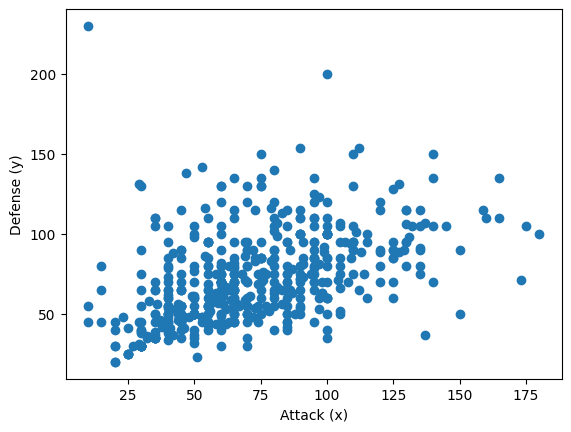

In [7]:
plt.figure()
plt.scatter(xtrain, ytrain)
plt.xlabel("Attack (x)")
plt.ylabel("Defense (y)")
plt.show()
plt.close()

## Define your linear model as $ypred=w.x$

In [8]:
def linear_model(x, w):
  ypred = w * x
  return ypred

## Define your error function (cost function) as $average((y-ypred)^2)$

In [9]:
def error_function(y, ypred):
  error = np.square(y - ypred).mean()
  return error

## Try multiple values of $w$ and calculate the error function with respect to $w$

### Define the the list of possible values of $w$ ranging from $-2.0$ to $8.0$

In [10]:
w_s = np.arange(start=-2.0, stop=8.0, step=0.01)
print(w_s)

[-2.00000000e+00 -1.99000000e+00 -1.98000000e+00 -1.97000000e+00
 -1.96000000e+00 -1.95000000e+00 -1.94000000e+00 -1.93000000e+00
 -1.92000000e+00 -1.91000000e+00 -1.90000000e+00 -1.89000000e+00
 -1.88000000e+00 -1.87000000e+00 -1.86000000e+00 -1.85000000e+00
 -1.84000000e+00 -1.83000000e+00 -1.82000000e+00 -1.81000000e+00
 -1.80000000e+00 -1.79000000e+00 -1.78000000e+00 -1.77000000e+00
 -1.76000000e+00 -1.75000000e+00 -1.74000000e+00 -1.73000000e+00
 -1.72000000e+00 -1.71000000e+00 -1.70000000e+00 -1.69000000e+00
 -1.68000000e+00 -1.67000000e+00 -1.66000000e+00 -1.65000000e+00
 -1.64000000e+00 -1.63000000e+00 -1.62000000e+00 -1.61000000e+00
 -1.60000000e+00 -1.59000000e+00 -1.58000000e+00 -1.57000000e+00
 -1.56000000e+00 -1.55000000e+00 -1.54000000e+00 -1.53000000e+00
 -1.52000000e+00 -1.51000000e+00 -1.50000000e+00 -1.49000000e+00
 -1.48000000e+00 -1.47000000e+00 -1.46000000e+00 -1.45000000e+00
 -1.44000000e+00 -1.43000000e+00 -1.42000000e+00 -1.41000000e+00
 -1.40000000e+00 -1.39000

### Define the empty list of errors for each value in $w_s$

In [11]:
list_errors = np.zeros(shape=(w_s.shape), dtype=np.float32)

### Go through all values in $w_s$ and calculate the error

In [12]:
for i in range(len(w_s)):
  w = w_s[i]
  ypred = linear_model(xtrain, w)
  list_errors[i] = error_function(ytrain, ypred)

### Plot the error function with respect to the values of $w_s$

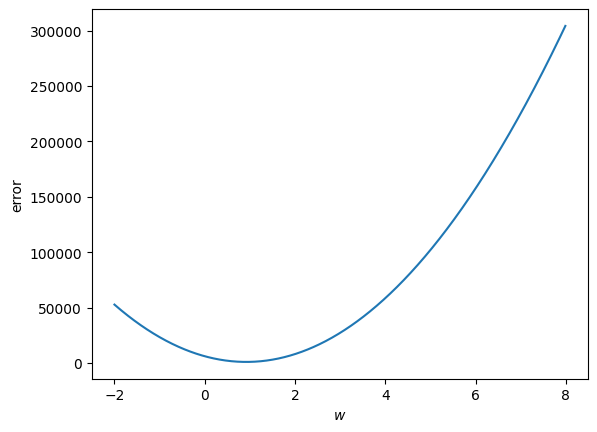

In [13]:
plt.figure()
plt.plot(w_s, list_errors)
plt.xlabel(r'$w$')
plt.ylabel("error")
plt.show()
plt.close()

### Find the $w$ that minimizes the error

In [14]:
index_w_best = list_errors.argmin()
error_train_min = list_errors.min()
w_best = w_s[index_w_best]

print("For w = "+str(w_best)+", the error on all training examples is = "+str(error_train_min))

For w = 0.9200000000000026, the error on all training examples is = 898.4006


### Evaluate the linear model for $w=w_{best}$ on the test set

In [15]:
ypred = linear_model(xtest, w_best)
error_test = error_function(ytest, ypred)
print("For w = "+str(w_best)+", the error on all testing examples is = "+str(error_test))

For w = 0.9200000000000026, the error on all testing examples is = 748.6369798449633


### Visualize the prediction with respect to the true values on the test set

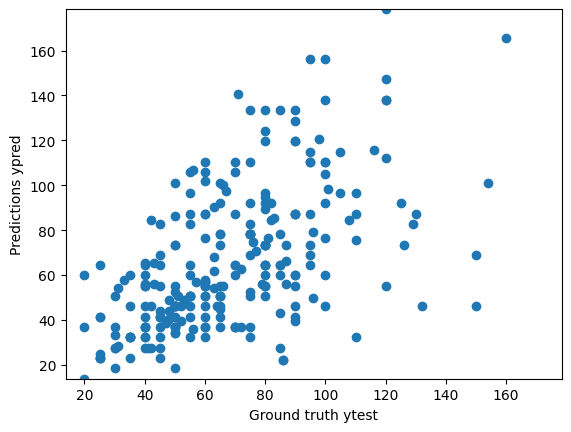

In [16]:
min_ypred, min_ytest = np.min(ypred), np.min(ytest)
max_ypred, max_ytest = np.max(ypred), np.max(ytest)

plt.figure()
plt.scatter(ytest, ypred)
plt.xlim(min(min_ypred, min_ytest), max(max_ypred, max_ytest))
plt.ylim(min(min_ypred, min_ytest), max(max_ypred, max_ytest))
plt.xlabel("Ground truth ytest")
plt.ylabel("Predictions ypred")
plt.show()
plt.close()

### Plot the straight line $y=w_{best} . x$

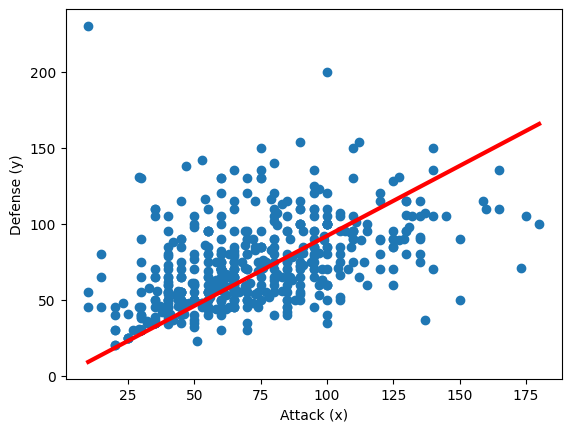

In [17]:
# Choose min and max borders
x1 = np.min(xtrain)
x2 = np.max(xtrain)

y1 = linear_model(x1, w_best)
y2 = linear_model(x2, w_best)

plt.figure()
plt.scatter(xtrain, ytrain)
plt.plot([x1,x2],[y1,y2], lw=3, color='red')
plt.xlabel("Attack (x)")
plt.ylabel("Defense (y)")
plt.show()
plt.close()

# Exercise

## How can we improve the precision (reduce error) on test set ?

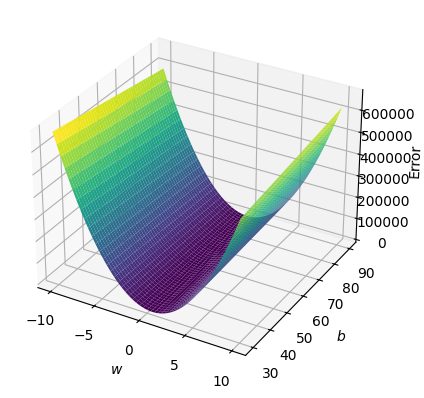

For w = 0.43999999999977746 and b = 40.900000000000155 the error on all training examples is = 627.2699434034395
For w = 0.43999999999977746 and b = 40.900000000000155 the error on all testing examples is = 501.5781364339779


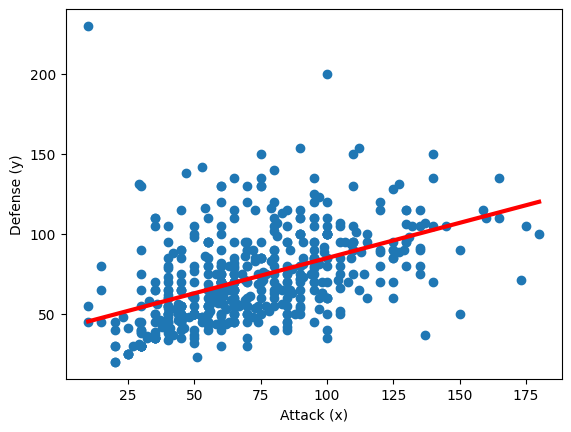

In [18]:
# your code here
# We can by learning the bias value

### Define the list of possible values of w and b
w_s = np.arange(start=-10.0, stop=10.0, step=0.01)
b_s = np.arange(start=30.0, stop=90.0, step=0.1)

### Define your linear model as y = w.x + b with bias b
def linear_model_bias(x, w, b):
    ypred = w * x + b
    return ypred

### Vectorized error computation (no loop needed)
# Convert to NumPy arrays for broadcasting
xtrain_np = np.array(xtrain)
ytrain_np = np.array(ytrain)

# Reshape for broadcasting: w_s (len(w_s), 1, 1), xtrain (1, len(xtrain), 1), b_s (1, 1, len(b_s))
W = w_s[:, None, None]  # Shape: (len(w_s), 1, 1)
X = xtrain_np[None, :, None]  # Shape: (1, len(xtrain), 1)
B = b_s[None, None, :]  # Shape: (1, 1, len(b_s))

# Compute all predictions at once: shape (len(w_s), len(xtrain), len(b_s))
ypred_all = W * X + B

# Compute errors: mean over samples (axis=1), shape (len(w_s), len(b_s))
list_errors_bias = np.mean((ypred_all - ytrain_np[None, :, None])**2, axis=1)

### Plot the error function with respect to the values of w_s and b_s
# Create meshgrid for w and b
W_mesh, B_mesh = np.meshgrid(w_s, b_s)
# Create the 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
# Plot the surface
ax.plot_surface(W_mesh, B_mesh, list_errors_bias.T, cmap='viridis')
# Labels
ax.set_xlabel(r'$w$')
ax.set_ylabel(r'$b$')
ax.set_zlabel('Error')
plt.show()
plt.close()

### Find the w and b that minimizes the error
index_w_best, index_b_best = np.unravel_index(list_errors_bias.argmin(), list_errors_bias.shape)
error_train_min = list_errors_bias.min()
w_best = w_s[index_w_best]
b_best = b_s[index_b_best]

print("For w = "+str(w_best)+" and b = "+str(b_best)+" the error on all training examples is = "+str(error_train_min))

### Evaluate the linear model for w=w_best and b=b_best on the test set
ypred_bias = linear_model_bias(xtest, w_best, b_best)
error_test = error_function(ytest, ypred_bias)
print("For w = "+str(w_best)+" and b = "+str(b_best)+" the error on all testing examples is = "+str(error_test))

### Plot the straight line y=w_best . x + b_best
# Choose min and max borders
x1 = np.min(xtrain)
x2 = np.max(xtrain)
y1 = linear_model_bias(x1, w_best, b_best)
y2 = linear_model_bias(x2, w_best, b_best)
plt.figure()
plt.scatter(xtrain, ytrain)
plt.plot([x1,x2],[y1,y2], lw=3, color='red')
plt.xlabel("Attack (x)")
plt.ylabel("Defense (y)")
plt.show()
plt.close()
